In [3]:
# Task 1

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [4]:
# Task 2

data = {
    "month": [
        "2023-01", "2023-02", "2023-03", "2023-04",
        "2023-05", "2023-06", "2023-07", "2023-08",
        "2023-09", "2023-10", "2023-11", "2023-12"
    ],
    "visits": [
        1200, 1350, 1100, 980,
        870, 760, 800, 950,
        1050, 1300, 1600, 1750
    ]
}

df_visits = pd.DataFrame(data)
df_visits["month"] = pd.to_datetime(df_visits["month"])

print(df_visits.dtypes)
print(df_visits.head())

# dateime64[ns]
# Can plot based on datetime and not just the string value

month     datetime64[ns]
visits             int64
dtype: object
       month  visits
0 2023-01-01    1200
1 2023-02-01    1350
2 2023-03-01    1100
3 2023-04-01     980
4 2023-05-01     870


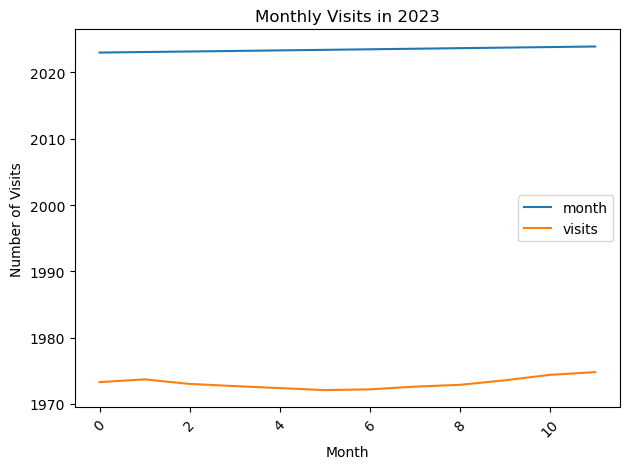

In [5]:
# Task 3

#df_visits.set_index("month", inplace=True)

df_visits[['month','visits']].plot(
    xlabel='Month',
    ylabel='Number of Visits',
    title='Monthly Visits in 2023',
    rot=45
)

plt.tight_layout()
plt.show()

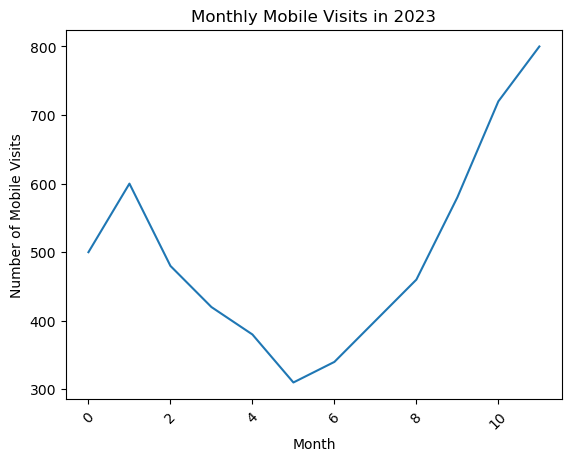

In [6]:
# Task 4

df_visits["mobile_visits"] = [
    500, 600, 480, 420,
    380, 310, 340, 400,
    460, 580, 720, 800
]

df_visits['mobile_visits'].plot(
    xlabel='Month',
    ylabel='Number of Mobile Visits',
    title='Monthly Mobile Visits in 2023',
    rot=45
)

plt.show()

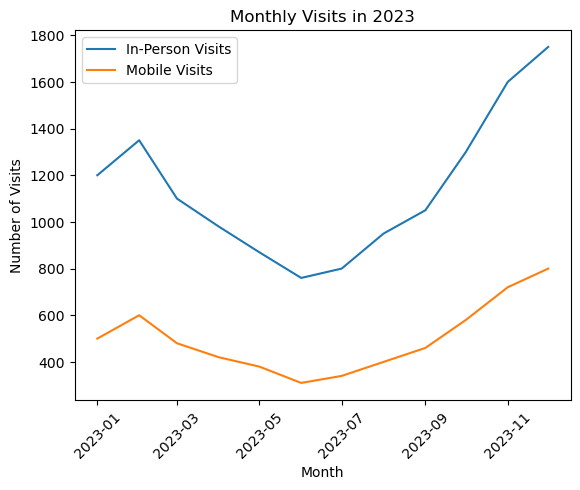

In [7]:
plt.plot(df_visits['month'], df_visits['visits'], label='In-Person Visits')
plt.plot(df_visits['month'], df_visits['mobile_visits'], label='Mobile Visits')

plt.title('Monthly Visits in 2023')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.legend()
plt.show()


In [8]:
# Task 5

ag_df = pd.read_csv('2011_ag.csv')
print(ag_df.shape)
print(ag_df.head())
print(ag_df.columns)

# 50 states
# A state per row
# Code column

(50, 17)
  code       state category  total exports   beef  pork  poultry   dairy  \
0   AL     Alabama    state        1390.63   34.4  10.6    481.0    4.06   
1   AK      Alaska    state          13.31    0.2   0.1      0.0    0.19   
2   AZ     Arizona    state        1463.17   71.3  17.9      0.0  105.48   
3   AR    Arkansas    state        3586.02   53.2  29.4    562.9    3.53   
4   CA  California    state       16472.88  228.7  11.1    225.4  929.95   

   fruits fresh  fruits proc  total fruits  veggies fresh  veggies proc  \
0           8.0         17.1         25.11            5.5           8.9   
1           0.0          0.0          0.00            0.6           1.0   
2          19.3         41.0         60.27          147.5         239.4   
3           2.2          4.7          6.88            4.4           7.1   
4        2791.8       5944.6       8736.40          803.2        1303.5   

   total veggies  corn  wheat   cotton  
0          14.33  34.9   70.0   317.61  
1

In [9]:
# Task 6

df_sorted = ag_df.sort_values('total exports', ascending=False)
df_sorted[['state', 'total exports']].head()

# California

,state,total exports
4,California,16472.88
14,Iowa,11273.76
12,Illinois,8709.48
22,Minnesota,7192.33
26,Nebraska,7114.13


In [10]:
# Task 7

px.choropleth(
    data_frame=ag_df,
    locations='code',
    locationmode='USA-states',
    color='total exports',
    scope='usa',
    color_continuous_scale='Greens',
    hover_name='state',
    title='2011 U.S. Agricultural Exports by State (Millions $)'
)

In [ ]:
# Task 8

px.choropleth(
    data_frame=ag_df,
    locations='code',
    locationmode='USA-states',
    color='total exports',
    scope='usa',
    color_continuous_scale='YlOrRd',
    hover_name='state',
    title='2011 U.S. Agricultural Exports by State (Millions $)'
)

# Y LORD?? colorscheme makes the highest-valued states a dark red color and
#  the lowest ones a pale yellow.

# The Y LORD?? scale is slightly easier because the scale changes colors
#   rather than just becoming a slightly darker version of the same color.

In [17]:
# Task 9

cities = {
    "city": [
        "Fresno", "Des Moines", "Lubbock",
        "Yakima", "Bakersfield", "Salinas"
    ],
    "lat": [36.7, 41.6, 33.6, 46.6, 35.4, 36.7],
    "lon": [-119.8, -93.6, -101.8, -120.5, -119.0, -121.7],
    "export_value": [4200, 3100, 2800, 2200, 3900, 1800]
}

df_cities = pd.DataFrame(cities)

px.scatter_geo(
    data_frame=df_cities,
    lat='lat',
    lon='lon',
    size='export_value',
    color='export_value',
    hover_name='city',
    scope='usa',
    title='Agricultural Export Value by City (Thousands $)',
    labels={'export_value':'Export Value ($K)'}
)


advanced tasks

In [25]:
# Task 11

px.choropleth(
    data_frame=ag_df,
    locations='code',
    locationmode='USA-states',
    color='corn',
    scope='usa',
    color_continuous_scale='YlOrBr',
    hover_name='state',
    title='2011 U.S. Agricultural Exports by State (Millions $)'
)
# The midwest is the most corny. This is expected

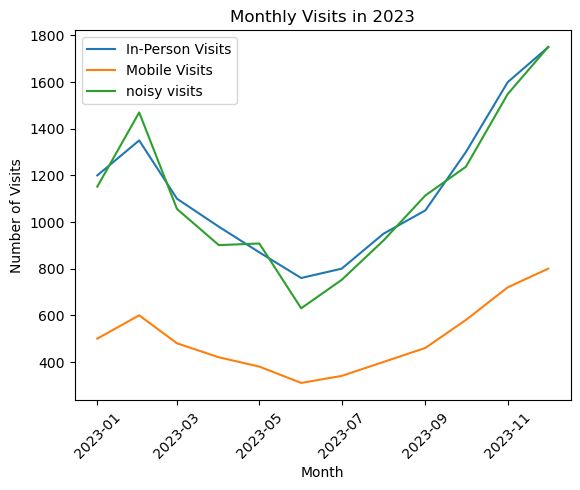

In [35]:
# Task 12

import numpy as np

np.random.seed(42)
df_visits["noisy_visits"] = (
    df_visits["visits"]
    + np.random.randint(-150, 150, size=len(df_visits))
)

plt.plot(df_visits['month'], df_visits['visits'], label='In-Person Visits')
plt.plot(df_visits['month'], df_visits['mobile_visits'], label='Mobile Visits')
plt.plot(df_visits['month'], df_visits['noisy_visits'], label='noisy visits')

plt.title('Monthly Visits in 2023')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# The noisy data looks the noisiest (duh). Data be noisy.

### Task 13

There seems to be a slight upward trend. More years' data would be helpful to see if this is an actual trend or just a seasonal pattern. Based on this one year, it seems like there are less visits over the summer and more over the winter. People visit the food bank more in the winter.

## Extra credit

In [43]:
px.choropleth(
    data_frame=ag_df,
    locations='code',
    locationmode='USA-states',
    color='total exports',
    scope='usa',
    color_continuous_scale='PuBuGn',
    hover_name='state',
    title='2011 U.S. Agricultural Exports by State (Millions $)',
    labels={'total exports': 'Total Exports (Millions of USD)'}
)

Reduntant Encoding is adding more visual cues to make clear what the chart is showing.
For color-blind individuals, it allows them to see the same meaning from the chart even if they can't distinguish the colors.

### Task 15

A choropleth map breaks up a map by region with distinct borders. A scatter map, on the other hand, shows exact points on a map and can use size of markers as an indicator of comparative values. Use choropleths when your data is segmented by general areas or places with borders. Use scatter maps when you have exact lat/long values.

Bar charts are a stationary diagram of measurements in different categories. Line plots show a continuation of one measurement at different times, showing changes of that value over time.

`pd.to_datetime()` is important to plot based on datetime and not just the string value. Without the conversion, it would plot each month as a separate category with its own measurement, not a continuous reading of the same measurement over time.